# Розвідувальний аналіз UA новин (EDA)

In [1]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('../data/gold/demo_cases.csv')
df['text_len'] = df['text'].apply(len)
print(df.groupby('expected_label')['text_len'].mean())


expected_label
FAKE          74.909091
REAL          61.666667
SUSPICIOUS    55.833333
Name: text_len, dtype: float64


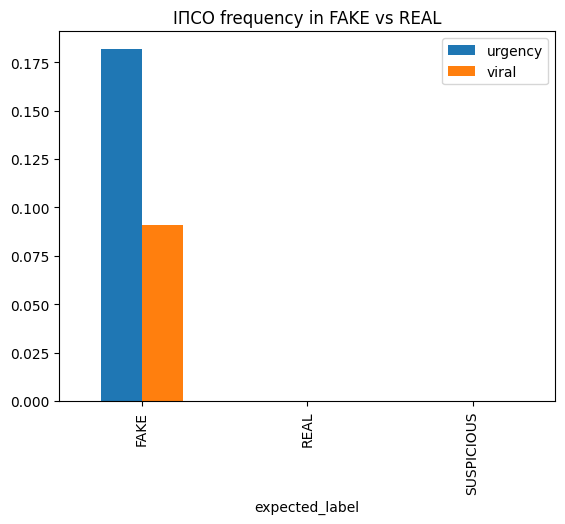

In [2]:
import re
patterns = {
    'urgency': r'(?i)терміново|зараз|негайно',
    'viral': r'(?i)поширте|пересилайте'
}
for name, pat in patterns.items():
    df[name] = df['text'].str.contains(pat).astype(int)

df.groupby('expected_label')[['urgency', 'viral']].mean().plot(kind='bar', title='ІПСО frequency in FAKE vs REAL')
plt.show()

In [3]:
try:
    from wordcloud import WordCloud
    print("Wordcloud installed")
except:
    print("Wordcloud not installed, skipping")

Wordcloud installed


## Висновки
FAKE новини мають значно більшу частоту ІПСО патернів.